## Importing Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Reading data from csv file

In [2]:
df=pd.read_csv('insurance.csv')

## Understanding the data

In [3]:
df.sample(5)

,age,sex,bmi,children,smoker,region,expenses
392,48,male,31.4,1,no,northeast,8964.06
981,34,male,21.4,0,no,northeast,4500.34
829,39,male,21.9,1,no,northwest,6117.49
582,39,male,45.4,2,no,southeast,6356.27
227,58,female,41.9,0,no,southeast,24227.34


In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


## Cleaning Data

In [8]:
df.drop_duplicates(inplace=True)

## Insight:
In this dataset we have not found unclean data and only one row is duplicated other data are seen clearning probably

## Exploratory Data Analysis
## Univariate Analysis

## Age Column Analysis

In [9]:
df['age'].nunique()

47

<Axes: xlabel='age', ylabel='Density'>

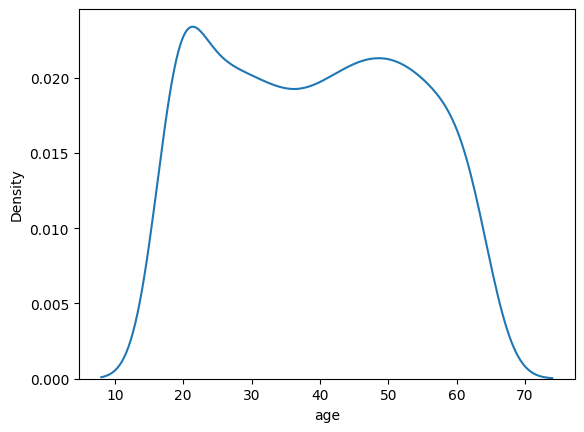

In [10]:
sns.kdeplot(data=df,x='age')

In [11]:
df['age'].skew()

np.float64(0.054780773126998195)

<Axes: xlabel='age', ylabel='Count'>

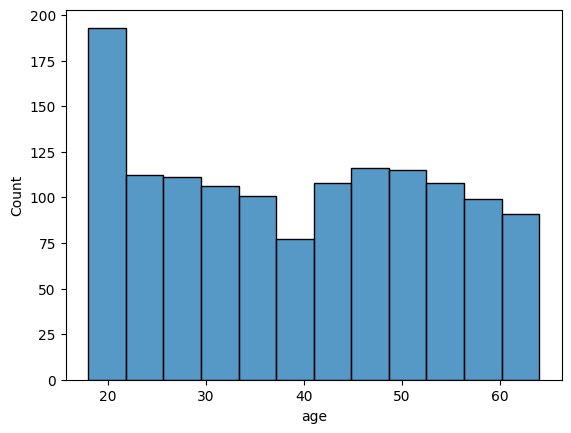

In [12]:
sns.histplot(data=df,x='age')

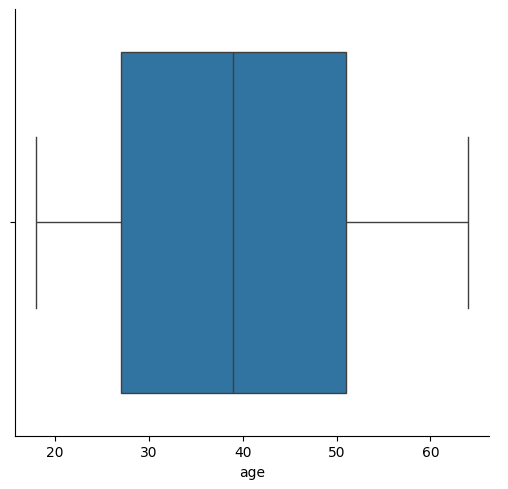

In [13]:
sns.catplot(data=df,x='age',kind='box')
plt.show()

## Insight:
* The data in age column is mainly distributed uniformly.
* The different age of person are similar occurated.



## Sex Column

In [14]:
result=df['sex'].value_counts()
result

sex
male      675
female    662
Name: count, dtype: int64

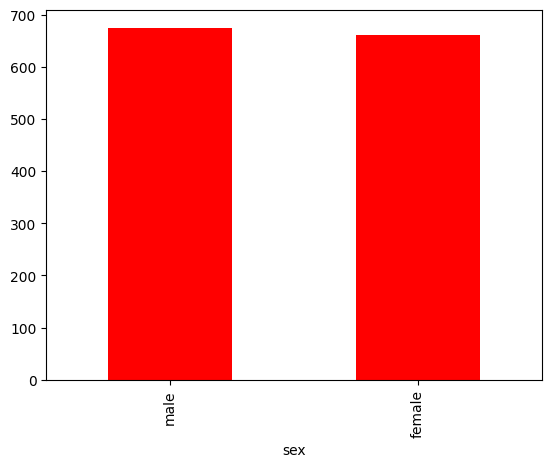

In [15]:
result.plot(kind='bar',color='red')
plt.show()

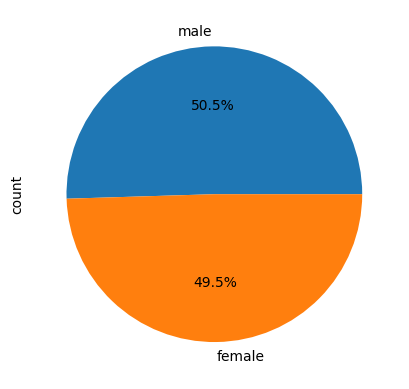

In [16]:
result.plot(kind='pie',autopct='%1.1f%%')
plt.show()

## Insight:
* Male and Female are roughly equaly occured in a dataset.
*This mean male and female of sex column are equally important to calculate insurance.

## Bmi Column

<Axes: >

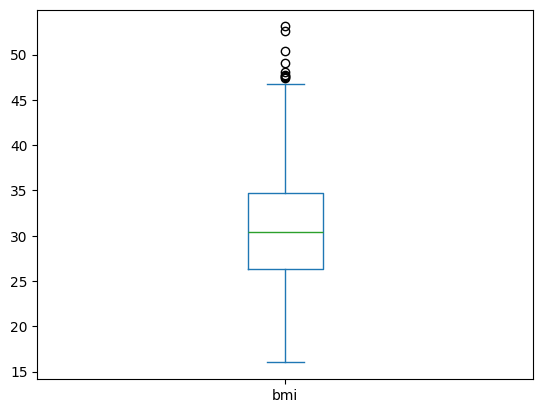

In [17]:
df['bmi'].plot(kind='box')

<Axes: xlabel='bmi', ylabel='Density'>

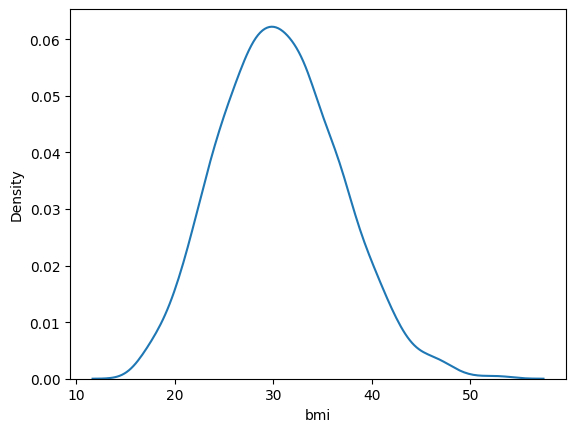

In [18]:
sns.kdeplot(data=df,x='bmi')

In [19]:
df['bmi'].skew()

np.float64(0.28446275054239506)

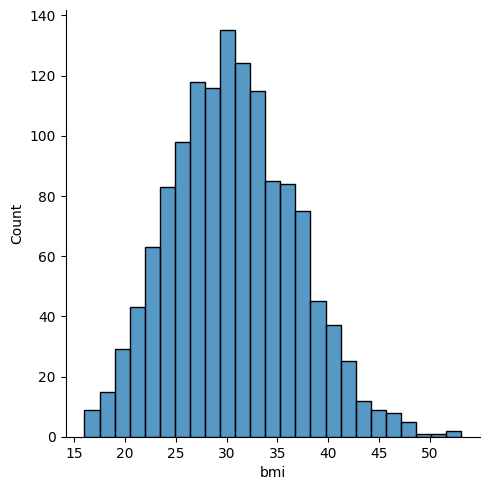

In [20]:
sns.displot(kind='hist',data=df,x='bmi')

In [21]:
upper=df['bmi'].mean()+3*df['bmi'].std()
lower=df['bmi'].mean()-3*df['bmi'].std()

In [22]:
df['bmi']=np.where(df['bmi']>upper,upper,np.where(df['bmi']<lower,lower,df['bmi']))

In [23]:
df[(df['bmi']>upper)|(df['bmi']<lower)]

,age,sex,bmi,children,smoker,region,expenses


## Insight:
* The data in bmi column is roughly normally distributed.
* The data in bmi column have some outlier value and we have handle it by using capping


## Children Column

In [24]:
result=df['children'].value_counts()
result

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

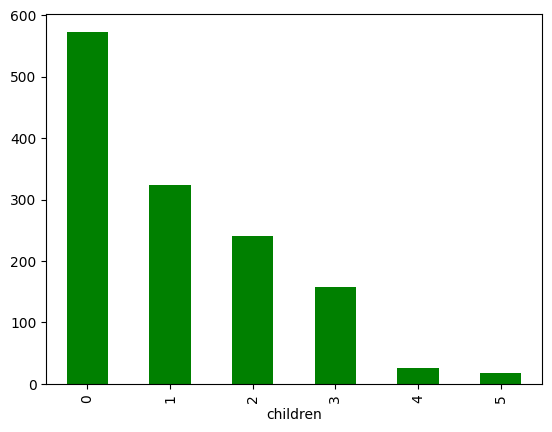

In [25]:
result.plot(kind='bar',color='green')
plt.show()

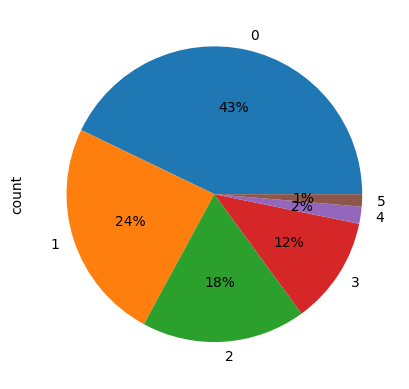

In [26]:
result.plot(kind='pie',autopct='%1.f%%')
plt.show()

## Insight:
* 43 percent of people in dataset have no children which is highest data in  children column and 1 percent of people have 5 children which is lowest data.
* We need to further investigate that having no child will less expenses or not and having more number of children will have more expenses or not.

## Smoker Column Analysis

In [27]:
result=df['smoker'].value_counts().reset_index(name='Number')

<BarContainer object of 2 artists>

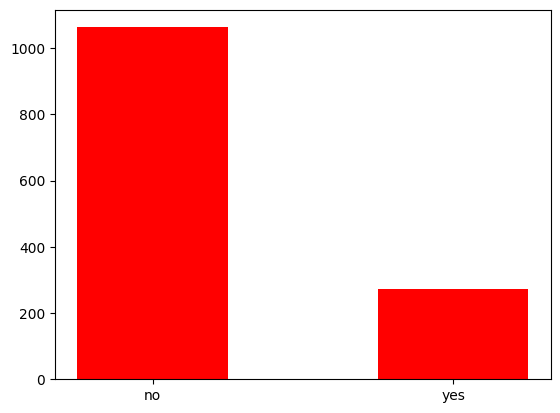

In [28]:
plt.bar(result['smoker'],result['Number'],color='red',width=0.5)

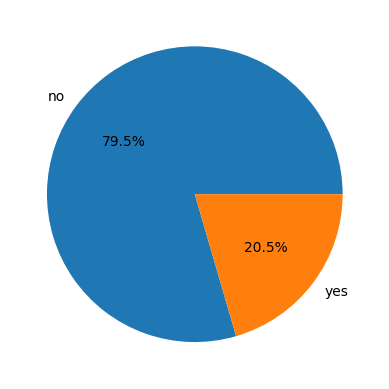

In [29]:
plt.pie(result['Number'],labels=result['smoker'],autopct='%1.1f%%')
plt.show()

## Insight:
* Around ~80 percent of people do not smoke and  around ~20 percent of people smoke.
* Smoker may have more expenses due to health related problem than non smoker.
* We will further analysis weather who smoke will have more expenses and no smoker have less expenses by analysis smoker and expenses class


## region column analysis

In [30]:
result=df['region'].value_counts()

<Axes: xlabel='region'>

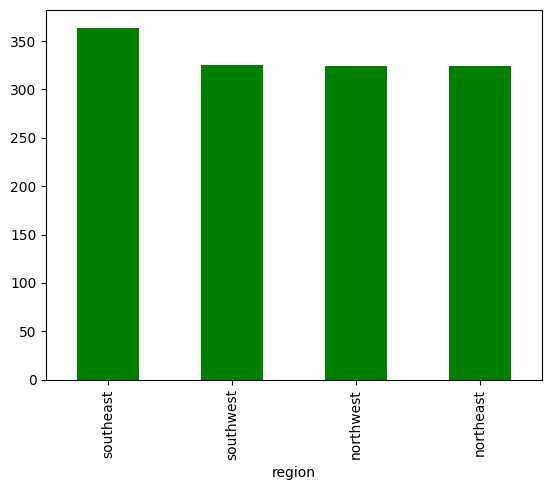

In [31]:
result.plot(kind='bar',color='green')

<Axes: ylabel='count'>

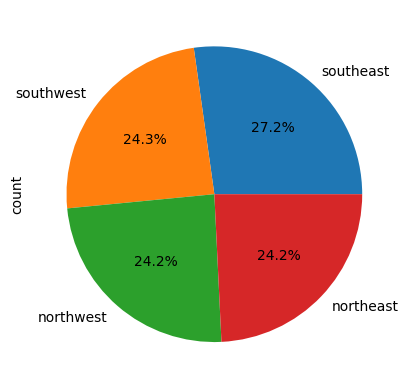

In [32]:
result.plot(kind='pie',autopct='%1.1f%%')

## Insight:
- The dataset includes four regions: northeast, northwest, southeast, and southwest.
- Three regions have roughly equal representation, while the southeast region has more individuals.
- Regional differences may impact medical expenses.Further we will conduct bivariate analysis between region and expenses to test correlation.

## Bivariate Analysis

## age and expenses column analysis

In [33]:
result=df[['age','expenses']].corr()

<Axes: >

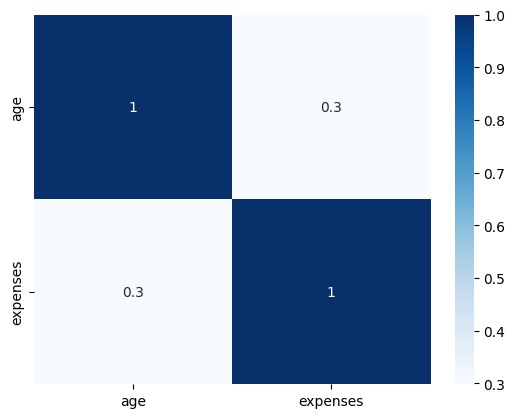

In [34]:
sns.heatmap(result,annot=True,cmap='Blues')

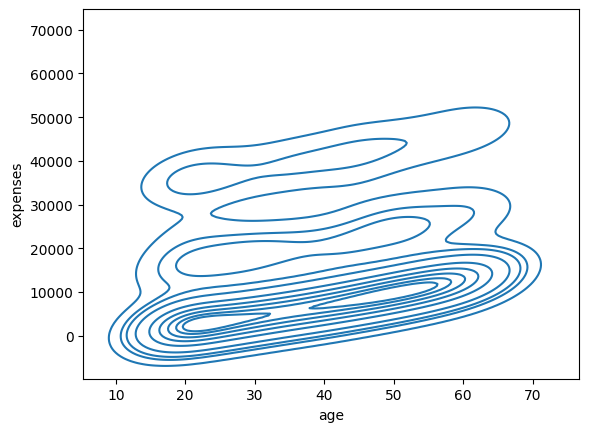

In [35]:
sns.kdeplot(data=df,x='age',y='expenses')
plt.show()

## Insight:
* The age and expenses column have weak positive correlation.
* We can interpret it as increasing age will have increase expenses.
* We can conclude that age column are necessary for predicting expenses column.

##  sex and expenses column

In [36]:
male_exp=df[df['sex']=='male']['expenses']

In [37]:
female_exp=df[df['sex']=='female']['expenses']

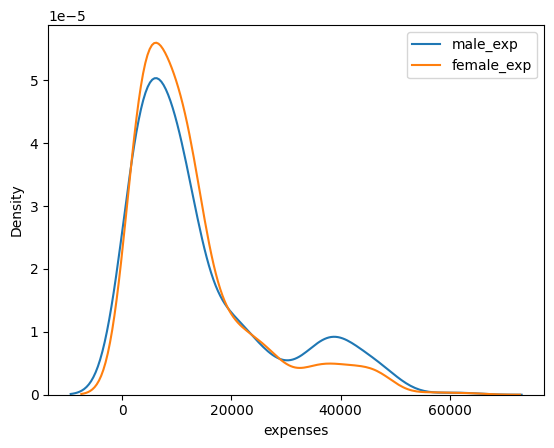

In [38]:
sns.kdeplot(male_exp,label='male_exp')
sns.kdeplot(female_exp,label='female_exp')
plt.legend()
plt.show()

In [39]:
## using ttest_ind for checking whether sex column is important for expenses or not
## H0:There is no significant difference between sex and  expenses column
## H1:There is significant difference between sex and expenses column
from scipy.stats import ttest_ind
t_value,p_value=ttest_ind(male_exp,female_exp)
print(t_value,p_value)
if p_value<0.05:
  print('Reject H0')
else:
  print('Fail to reject H0')

2.1243916010309483 0.03382076738656679
Reject H0


# Insights:
* The KDE plot indicates that the expense distributions for males and females are not similar.
* An independent t-test was performed and the p-value showed a statistically significant difference between the two groups.
* Hence, the sex feature may be useful for predicting medical expenses

In [40]:
result=df[['bmi','expenses']].corr()
result

,bmi,expenses
bmi,1.000000,0.198905
expenses,0.198905,1.000000


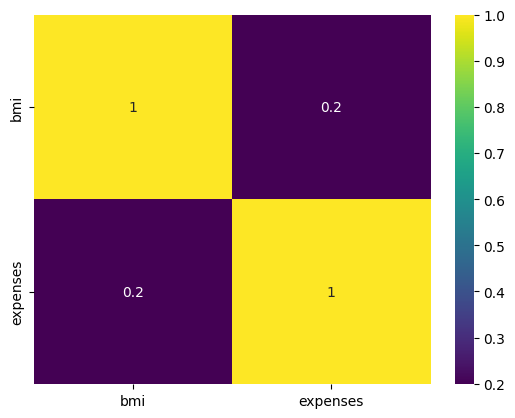

In [41]:
sns.heatmap(result,annot=True,cmap='viridis')
plt.show()

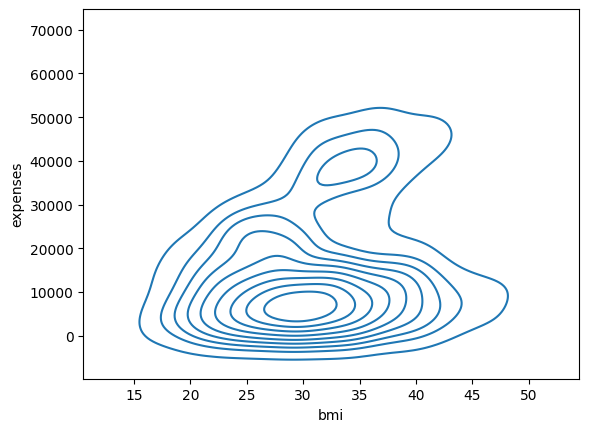

In [42]:
sns.kdeplot(data=df,x='bmi',y='expenses')
plt.show()

## Insight:
* bmi and expenses have  weak positive correlation.
* It indicating that on increasing bmi slightly expenses will also increases.
* We need to have bmi column for predicting expenses but may other column like smoker,age may need for predicting expenses.

## children and expenses column analysis

<Axes: xlabel='children', ylabel='expenses'>

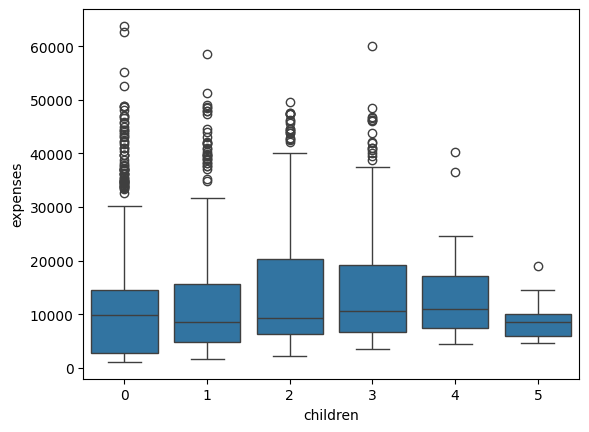

In [43]:
sns.boxplot(data=df,x='children',y='expenses')

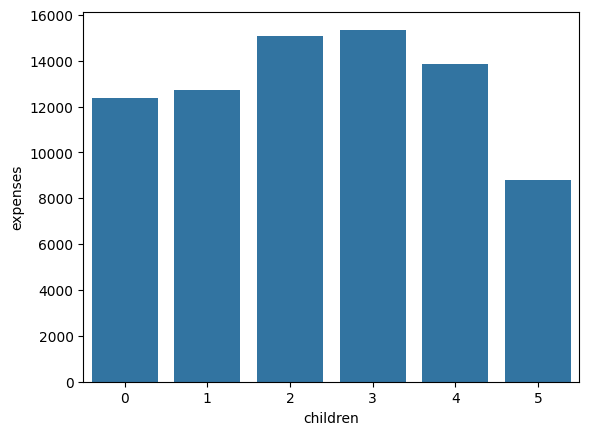

In [44]:
sns.barplot(data=df,x='children',y='expenses',errorbar=None)
plt.show()

## Insight:
* The boxplot shows that the distribution of expenses is fairly similar across child categories, with no major differences.
* The bar graph indicates that having more children does not consistently lead to higher expenses; only families with 2–3 children show slightly elevated costs.
*  The children column may contribute to expense prediction, but its impact is weaker compared to stronger predictors such as age or smoker status. It should be retained as a supporting feature rather than a primary driver.

In [45]:
smoker_yes=df[df['smoker']=='yes']['expenses']
smoker_no=df[df['smoker']=='no']['expenses']

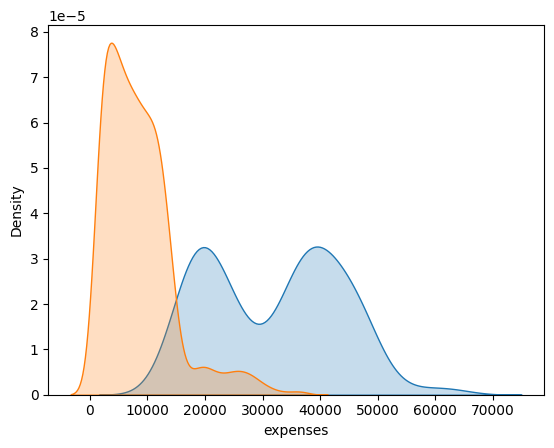

In [46]:
sns.kdeplot(smoker_yes,label='smoker_yes',fill=True)
sns.kdeplot(smoker_no,label='smoker_no',fill=True)
plt.show()

In [47]:
#H0:There is no significane difference between smoker and non smoker on expenses column.
#H1:There is significant difference between smoker and non smoker on expenses column.
t_value,p_value=ttest_ind(smoker_yes,smoker_no)
print(t_value,p_value)
if p_value<0.05:
  print('Reject H0')
else:
  print('Fail to reject Ho')

46.64479451267084 1.406724235056543e-282
Reject H0


## Insight:
* From kdeplot we can clearly see that distribution of smoker and non_smoker on expenses column show much difference.
* We verified it using ttest statistics which show that smoker and non-smoker have significant difference.
* We can conclude that smoker column is important factor for predicting for expenses column.

## region and expenses column analysis

In [48]:
df.groupby('region')['expenses'].mean()

region
northeast    13406.384691
northwest    12450.840648
southeast    14735.411538
southwest    12346.937908
Name: expenses, dtype: float64

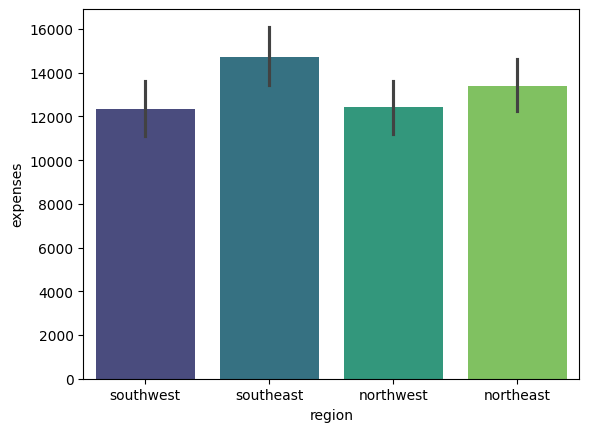

In [49]:
sns.barplot(data=df,x='region',y='expenses',palette='viridis',hue='region',legend=False)
plt.show()

## Insight:
* : The southeast region shows the highest average medical expenses, while southwest and northwest have the lowest. The northeast region falls in between
* This indicates that individuals in the southeast tend to spend more on healthcare, possibly due to lifestyle, cost of medical services.
* The region column should be retained for expense prediction, but its influence appears moderate compared to stronger predictors like smoker status or age.

## Multivariate Analysis

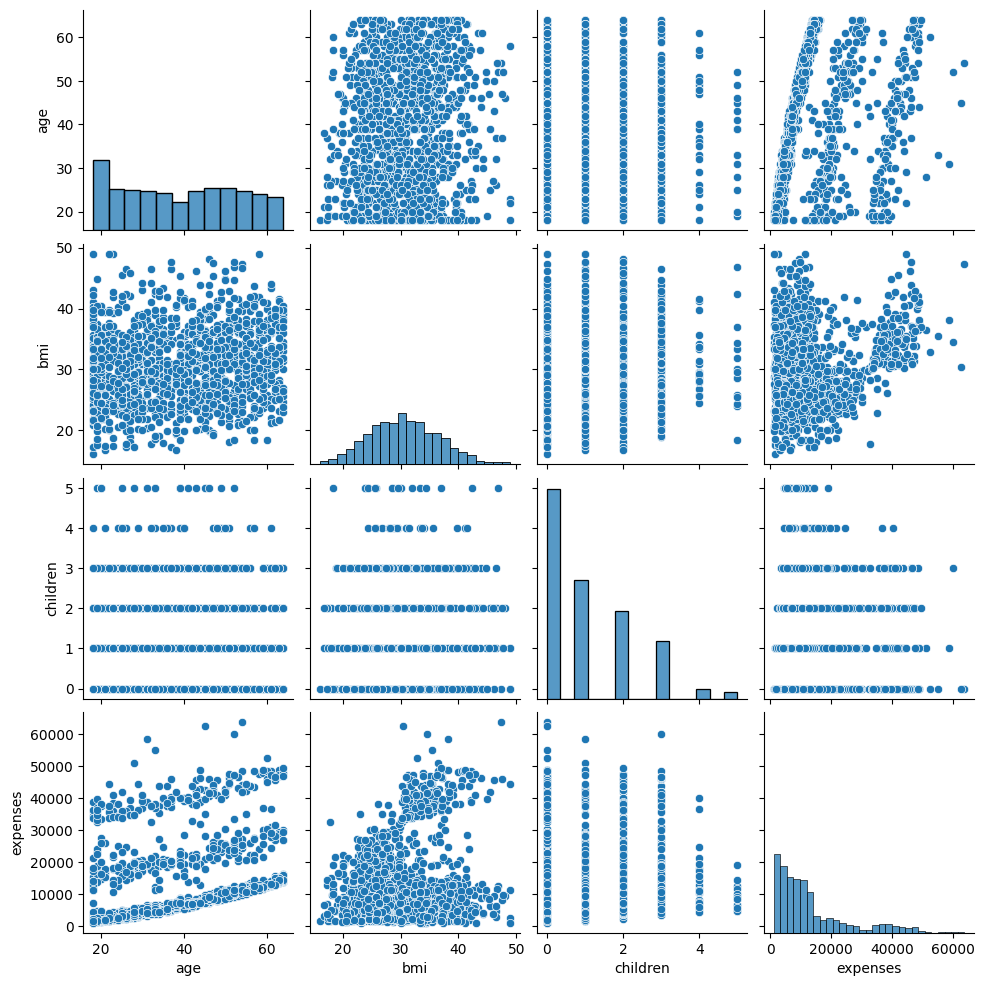

In [50]:
sns.pairplot(data=df)
plt.show()

In [51]:
temp=df[['age','bmi','expenses']].corr()
temp

,age,bmi,expenses
age,1.000000,0.111328,0.298308
bmi,0.111328,1.000000,0.198905
expenses,0.298308,0.198905,1.000000


<Axes: >

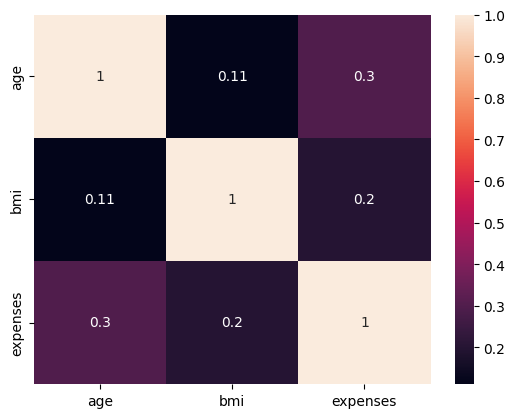

In [52]:
sns.heatmap(temp,annot=True)

## We have perform all eda analysis,now we are need to perform Machine Learning portion

In [53]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet,SGDRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.model_selection import GridSearchCV
import pickle
import joblib

In [54]:
x=df.drop(columns='expenses')
y=df['expenses']


In [56]:
def func(x):
  if x<=1:
    return 'lower expenses'
  elif x>=2 and x<=3:
    return 'high expenses'
  else:
    return 'medium expenses'


In [57]:
x['children_expense']=x['children'].apply(func)

In [58]:
x=x.drop(columns='children')

In [59]:
x.sample()

,age,sex,bmi,smoker,region,children_expense
375,23,female,28.3,yes,northwest,lower expenses


In [60]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=3)

In [61]:
clt=ColumnTransformer(transformers=[
    ('ohe',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'),['sex','smoker','region','children_expense']),
    ('ss',StandardScaler(),['age','bmi'])
],remainder='passthrough')

In [62]:
pipe=Pipeline([
    ('preprocessor',clt),
    ('model',SGDRegressor(max_iter=1000,learning_rate='invscaling',eta0=0.01))
])

In [63]:
pipe.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('ss', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [64]:
y_pred=pipe.predict(x_test)

In [65]:
pipe.named_steps['model'].coef_

array([ -193.57029673, 24268.35152797,   -64.96255656,  -976.00186223,
        -685.45944639, -1040.7007172 ,   806.07193298,  3663.19261108,
        2039.72079382])

In [66]:
r2_score(y_test,y_pred)

0.7610287502293871

In [67]:
np.mean(cross_val_score(pipe,x,y,cv=5,scoring='r2'))

np.float64(0.7472149349980446)

In [68]:
mean_absolute_error(y_test,y_pred)

4181.6477394070835

In [70]:
with open('pipe.pkl','wb') as f:
    pickle.dump(pipe,f)